In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generación del Dataset (Kilometraje 'x' y Consumo 'y')

x_datos = [50, 80, 120, 150, 200, 250, 300, 350, 400, 450]
y_datos = [14.2, 12.8, 22.5, 21.0, 31.8, 33.2, 38.5, 49.0, 50.2, 58.0]

print("Dataset de viajes:")
for i in range(len(x_datos)):
    print(f"Viaje {i+1}: x = {x_datos[i]} km -> y = {y_datos[i]} Litros")

Dataset de viajes:
Viaje 1: x = 50 km -> y = 14.2 Litros
Viaje 2: x = 80 km -> y = 12.8 Litros
Viaje 3: x = 120 km -> y = 22.5 Litros
Viaje 4: x = 150 km -> y = 21.0 Litros
Viaje 5: x = 200 km -> y = 31.8 Litros
Viaje 6: x = 250 km -> y = 33.2 Litros
Viaje 7: x = 300 km -> y = 38.5 Litros
Viaje 8: x = 350 km -> y = 49.0 Litros
Viaje 9: x = 400 km -> y = 50.2 Litros
Viaje 10: x = 450 km -> y = 58.0 Litros


In [ ]:
# Encontrar los mejores valores de b y w 
mejor_b = 0.0
mejor_w = 0.0
menor_error = float('inf')

# Probamos rangos posibles para b y w usando bucles repetitivos
for b_int in range(0, 150, 5):         
    b = b_int / 10.0                   # Probar b desde 0.0 hasta 15.0
    for w_int in range(5, 25, 1):      
        w = w_int / 100.0              # Probar w desde 0.05 hasta 0.25
        
        error_acumulado = 0.0
        
        for i in range(len(x_datos)):
            y_predicho = b + w * x_datos[i]
            diferencia = y_datos[i] - y_predicho
            error_acumulado += diferencia ** 2  # Error cuadrático acumulado
        
        if error_acumulado < menor_error:
            menor_error = error_acumulado
            mejor_b = b
            mejor_w = w

print(f"Mejor valor de b (intercepto): {mejor_b:.2f}")
print(f"Mejor valor de w (pendiente):  {mejor_w:.2f}")
print(f"Menor error cuadrático total:  {menor_error:.4f}")

Mejor valor de b (intercepto): 7.50
Mejor valor de w (pendiente):  0.11
Menor error cuadrático total:  50.1500


In [ ]:
# 3. Inferencias para 10 nuevos valores de x
nuevos_x = [60, 100, 140, 180, 220, 260, 310, 370, 420, 480]
inferencias_y = []

print("--- INFERENCIAS PARA 10 NUEVOS VALORES ---")
for x_nuevo in nuevos_x:
    y_calculado = mejor_b + mejor_w * x_nuevo
    inferencias_y.append(y_calculado)
    print(f"Para x = {x_nuevo} km -> Consumo estimado (y) = {y_calculado:.2f} Litros")

--- INFERENCIAS PARA 10 NUEVOS VALORES ---
Para x = 60 km -> Consumo estimado (y) = 14.10 Litros
Para x = 100 km -> Consumo estimado (y) = 18.50 Litros
Para x = 140 km -> Consumo estimado (y) = 22.90 Litros
Para x = 180 km -> Consumo estimado (y) = 27.30 Litros
Para x = 220 km -> Consumo estimado (y) = 31.70 Litros
Para x = 260 km -> Consumo estimado (y) = 36.10 Litros
Para x = 310 km -> Consumo estimado (y) = 41.60 Litros
Para x = 370 km -> Consumo estimado (y) = 48.20 Litros
Para x = 420 km -> Consumo estimado (y) = 53.70 Litros
Para x = 480 km -> Consumo estimado (y) = 60.30 Litros


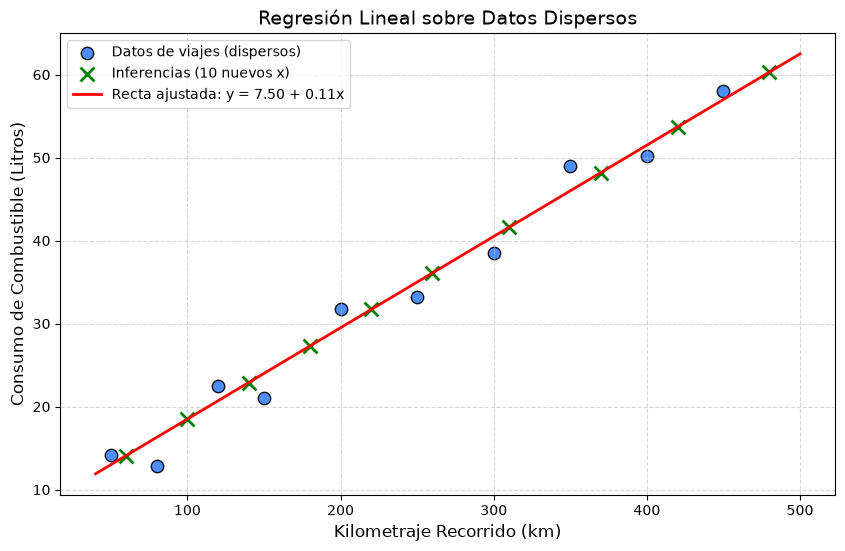

In [ ]:
# Graficación de los resultados dispersos y la recta 
plt.figure(figsize=(10, 6))

# Puntos del dataset dispersos
plt.scatter(x_datos, y_datos, color='#3b82f6', s=80, edgecolors='k', alpha=0.9, label='Datos de viajes (dispersos)')
plt.scatter(nuevos_x, inferencias_y, color='green', marker='x', s=100, linewidths=2, label='Inferencias (10 nuevos x)')

# Recta de regresión ajustada
x_linea = np.linspace(40, 500, 100)
y_linea = mejor_b + mejor_w * x_linea
plt.plot(x_linea, y_linea, color='red', linewidth=2, label=f'Recta ajustada: y = {mejor_b:.2f} + {mejor_w:.2f}x')

plt.xlabel('Kilometraje Recorrido (km)', fontsize=12)
plt.ylabel('Consumo de Combustible (Litros)', fontsize=12)
plt.title('Regresión Lineal sobre Datos Dispersos', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()